<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/%EB%85%BC%EB%AC%B8%EC%8A%A4%ED%84%B0%EB%94%94_OB3%EC%A1%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

DATA_PATH = "synthetic_TEAMS_RA_practice.csv"
TARGET = "recidivism_2yr"

In [ ]:
# 데이터 불러오기 및 전처리
df = pd.read_csv(DATA_PATH)

df = df.dropna().copy()

y = df[TARGET].astype(int)
X_raw = df.drop(columns=[TARGET])
X = pd.get_dummies(X_raw, drop_first=True)

print("전체 데이터 크기:", X.shape)
print("전체 y 분포")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

전체 데이터 크기: (1736, 10)
전체 y 분포
recidivism_2yr
0    1432
1     304
Name: count, dtype: int64
recidivism_2yr
0    0.825
1    0.175
Name: proportion, dtype: float64


In [ ]:
# Train / Test 분리 (7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

print("\n[Train 분포]")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))

print("\n[Test 분포]")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(3))


[Train 분포]
recidivism_2yr
0    1002
1     213
Name: count, dtype: int64
recidivism_2yr
0    0.825
1    0.175
Name: proportion, dtype: float64

[Test 분포]
recidivism_2yr
0    430
1     91
Name: count, dtype: int64
recidivism_2yr
0    0.825
1    0.175
Name: proportion, dtype: float64


In [ ]:
# 로지스틱 회귀 모델 생성 함수
def make_logit():
    return LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=10000
    )

In [ ]:
# 성능 평가 함수
def get_perf_from_prob(y_true, prob, cutoff=0.5):
    """
    Accuracy  : 전체 분류 정확도
    Sensitivity: 양성 클래스, 즉 재입원자/재범자 탐지율
    Specificity: 음성 클래스, 즉 비재입원자/비재범자 탐지율
    AUC       : cutoff와 무관한 ROC-AUC
    """
    pred = (prob >= cutoff).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    acc = accuracy_score(y_true, pred)
    sens = tp / (tp + fn) if (tp + fn) != 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) != 0 else np.nan
    auc = roc_auc_score(y_true, prob)

    return pd.Series({
        "Accuracy": acc,
        "Sensitivity": sens,
        "Specificity": spec,
        "AUC": auc
    })


def print_table(title, table):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    print(table.round(3))


In [ ]:
#[표 1] SMOTE 미적용 vs 적용

# SMOTE 미적용 로지스틱 회귀
logit_raw = make_logit()
logit_raw.fit(X_train, y_train)

prob_raw = logit_raw.predict_proba(X_test)[:, 1]
perf_raw = get_perf_from_prob(y_test, prob_raw, cutoff=0.5)


# SMOTE 적용 로지스틱 회귀
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n[SMOTE 적용 전 train 분포]")
print(y_train.value_counts())

print("\n[SMOTE 적용 후 train 분포]")
print(y_train_smote.value_counts())

logit_smote = make_logit()
logit_smote.fit(X_train_smote, y_train_smote)

prob_smote = logit_smote.predict_proba(X_test)[:, 1]
perf_smote = get_perf_from_prob(y_test, prob_smote, cutoff=0.5)


table1 = pd.DataFrame({
    "SMOTE 미적용": perf_raw,
    "SMOTE 적용": perf_smote
}).T

print_table("[표 1] 로지스틱 회귀: SMOTE 적용 전후 test 성능", table1)




[SMOTE 적용 전 train 분포]
recidivism_2yr
0    1002
1     213
Name: count, dtype: int64

[SMOTE 적용 후 train 분포]
recidivism_2yr
1    1002
0    1002
Name: count, dtype: int64

[표 1] 로지스틱 회귀: SMOTE 적용 전후 test 성능
           Accuracy  Sensitivity  Specificity    AUC
SMOTE 미적용     0.881        0.451        0.972  0.890
SMOTE 적용      0.797        0.769        0.802  0.868


논문 :
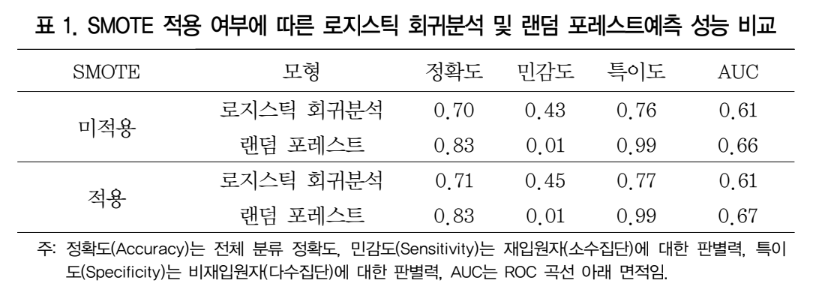

In [ ]:
# [표 2] 10-fold 5-repeats 교차검증

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=SEED
)

logit_pipe = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("logit", make_logit())
])

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "sensitivity": make_scorer(recall_score, pos_label=1, zero_division=0),
    "specificity": make_scorer(recall_score, pos_label=0, zero_division=0),
    "auc": "roc_auc"
}

cv_results = cross_validate(
    logit_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

table2 = pd.DataFrame({
    "Accuracy": [cv_results["test_accuracy"].mean()],
    "Sensitivity": [cv_results["test_sensitivity"].mean()],
    "Specificity": [cv_results["test_specificity"].mean()],
    "AUC": [cv_results["test_auc"].mean()]
}, index=["Logistic Regression CV"])

print_table("[표 2] 로지스틱 회귀: 10-fold 5-repeats CV 평균 성능", table2)




[표 2] 로지스틱 회귀: 10-fold 5-repeats CV 평균 성능
                        Accuracy  Sensitivity  Specificity    AUC
Logistic Regression CV     0.784        0.745        0.792  0.853


논문 :
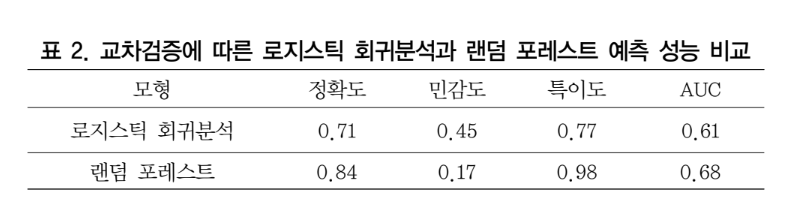

In [ ]:
# 최종 모델: train 전체에 SMOTE 적용 후 적합
final_logit_pipe = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("logit", make_logit())
])

final_logit_pipe.fit(X_train, y_train)

prob_test = final_logit_pipe.predict_proba(X_test)[:, 1]
test_perf_05 = get_perf_from_prob(y_test, prob_test, cutoff=0.5)

print_table("[최종 test 성능] cutoff = 0.5", test_perf_05.to_frame().T)




[최종 test 성능] cutoff = 0.5
   Accuracy  Sensitivity  Specificity    AUC
0     0.797        0.769        0.802  0.868


In [ ]:
# [표 4, 표 5] Youden Index 기반 cutoff 선정

cv_for_cutoff = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

oof_prob = cross_val_predict(
    logit_pipe,
    X_train,
    y_train,
    cv=cv_for_cutoff,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, oof_prob)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_cutoff = thresholds[best_idx]

print("\n최적 임계값, Youden Index 기준:", round(best_cutoff, 3))

# 최종 모델의 test 예측확률에 cutoff 적용
test_perf_youden = get_perf_from_prob(
    y_test,
    prob_test,
    cutoff=best_cutoff
)

pred_youden = (prob_test >= best_cutoff).astype(int)
cm_youden = confusion_matrix(y_test, pred_youden)

print("\n[표 4] Youden cutoff 적용 혼동행렬")
print(pd.DataFrame(
    cm_youden,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
))

print_table("[표 5] 로지스틱 회귀: Youden cutoff 적용 test 성능",
            test_perf_youden.to_frame().T)




최적 임계값, Youden Index 기준: 0.39

[표 4] Youden cutoff 적용 혼동행렬
          Pred 0  Pred 1
Actual 0     304     126
Actual 1      17      74

[표 5] 로지스틱 회귀: Youden cutoff 적용 test 성능
   Accuracy  Sensitivity  Specificity    AUC
0     0.726        0.813        0.707  0.868


논문 :
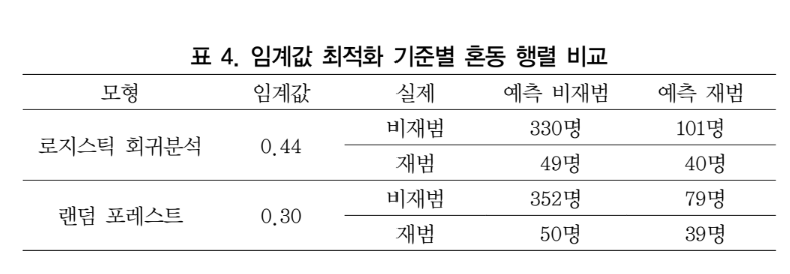

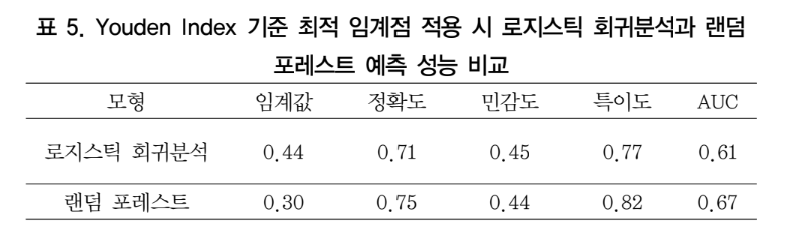

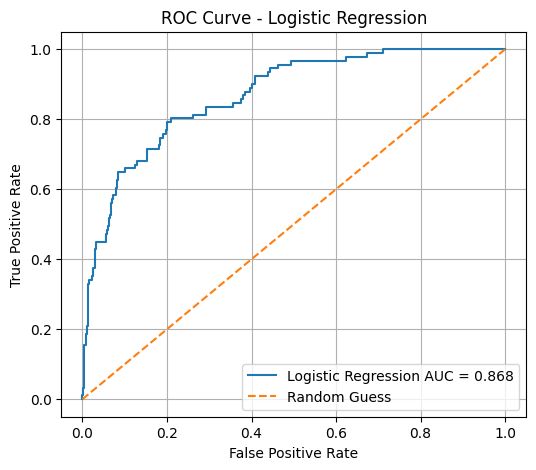

In [ ]:
# ROC curve 시각화
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, prob_test)
auc_test = roc_auc_score(y_test, prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, label=f"Logistic Regression AUC = {auc_test:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/ESAA/project/synthetic_TEAMS_RA_practice.csv"

TARGET = "recidivism_2yr"

RANDOM_STATE = 42
TEST_SIZE = 0.30
THRESHOLD = 0.50

df = pd.read_csv(DATA_PATH)

print("데이터 크기:", df.shape)
print("\n종속변수 분포")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 크기: (1736, 11)

종속변수 분포
recidivism_2yr
0    1432
1     304
Name: count, dtype: int64
recidivism_2yr
0    0.825
1    0.175
Name: proportion, dtype: float64


In [ ]:
# 종속변수, 독립변수 분리
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

print("\n범주형 변수:", cat_cols)
print("연속형/수치형 변수:", num_cols)



범주형 변수: ['gender']
연속형/수치형 변수: ['age_at_admission', 'first_offense_age', 'delinquency_count', 'letters_received', 'runaway_count', 'antisocial_score', 'adhd_score', 'runaway_history', 'smoking_start_age']


In [ ]:
# 전처리기 생성 함수
#    - 범주형 변수는 One-hot encoding
#    - 수치형 변수는 그대로 사용
def make_onehot_encoder():
    try:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse=False
        )


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", make_onehot_encoder(), cat_cols),
            ("num", "passthrough", num_cols)
        ],
        remainder="drop"
    )

In [ ]:
# Random Forest Pipeline 생성 함수
#    use_smote=False: SMOTE 미적용
#    use_smote=True : 전처리 후 SMOTE 적용
def make_rf_pipeline(use_smote=False):
    rf = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    if use_smote:
        return Pipeline(steps=[
            ("preprocess", make_preprocessor()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("rf", rf)
        ])
    else:
        return Pipeline(steps=[
            ("preprocess", make_preprocessor()),
            ("rf", rf)
        ])

In [ ]:
# 성능지표 계산 함수
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "AUC": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [ ]:
# Train/Test 분리
#    stratify=y: 재범/비재범 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain 종속변수 분포")
print(y_train.value_counts())

print("\nTest 종속변수 분포")
print(y_test.value_counts())


Train 종속변수 분포
recidivism_2yr
0    1002
1     213
Name: count, dtype: int64

Test 종속변수 분포
recidivism_2yr
0    430
1     91
Name: count, dtype: int64


In [ ]:
#    10-fold CV 미적용
#    단일 Train/Test split으로 평가
holdout_results = []
holdout_roc = {}

for use_smote in [False, True]:

    label = (
        "Train/Test + SMOTE X"
        if not use_smote
        else "Train/Test + SMOTE O"
    )

    model = make_rf_pipeline(use_smote=use_smote)

    # SMOTE 적용 모델의 경우:
    # X_train 내부에서만 SMOTE가 적용
    model.fit(X_train, y_train)

    # Test set은 SMOTE 적용하지 않은 원래 분포 그대로 평가
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = calculate_metrics(
        y_test,
        y_prob,
        threshold=THRESHOLD
    )

    holdout_results.append({
        "Evaluation": "Train/Test split",
        "SMOTE": "X" if not use_smote else "O",
        **metrics
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    holdout_roc[label] = (fpr, tpr, metrics["AUC"])

In [ ]:
#    10-fold CV 적용
#    전체 데이터를 10개 fold로 나누어 교차검증
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []
cv_roc = {}

for use_smote in [False, True]:

    label = (
        "10-fold CV + SMOTE X"
        if not use_smote
        else "10-fold CV + SMOTE O"
    )

    model = make_rf_pipeline(use_smote=use_smote)

    y_prob_cv = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    metrics = calculate_metrics(
        y,
        y_prob_cv,
        threshold=THRESHOLD
    )

    cv_results.append({
        "Evaluation": "10-fold CV",
        "SMOTE": "X" if not use_smote else "O",
        **metrics
    })

    fpr, tpr, _ = roc_curve(y, y_prob_cv)
    cv_roc[label] = (fpr, tpr, metrics["AUC"])


In [ ]:
# 성능 비교표
result_df = pd.DataFrame(holdout_results + cv_results)

display_cols = [
    "Evaluation",
    "SMOTE",
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]

result_df = result_df[display_cols]

print("\n==============================")
print("Random Forest 성능 비교 결과")
print("==============================")
print(result_df.round(3))

# 결과 저장
result_df.to_csv(
    "rf_performance_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)


Random Forest 성능 비교 결과
         Evaluation SMOTE  Accuracy  Sensitivity  Specificity    AUC    TN  \
0  Train/Test split     X     0.862        0.330        0.974  0.838   419   
1  Train/Test split     O     0.843        0.571        0.900  0.844   387   
2        10-fold CV     X     0.857        0.326        0.969  0.836  1388   
3        10-fold CV     O     0.832        0.510        0.901  0.837  1290   

    FP   FN   TP  
0   11   61   30  
1   43   39   52  
2   44  205   99  
3  142  149  155  


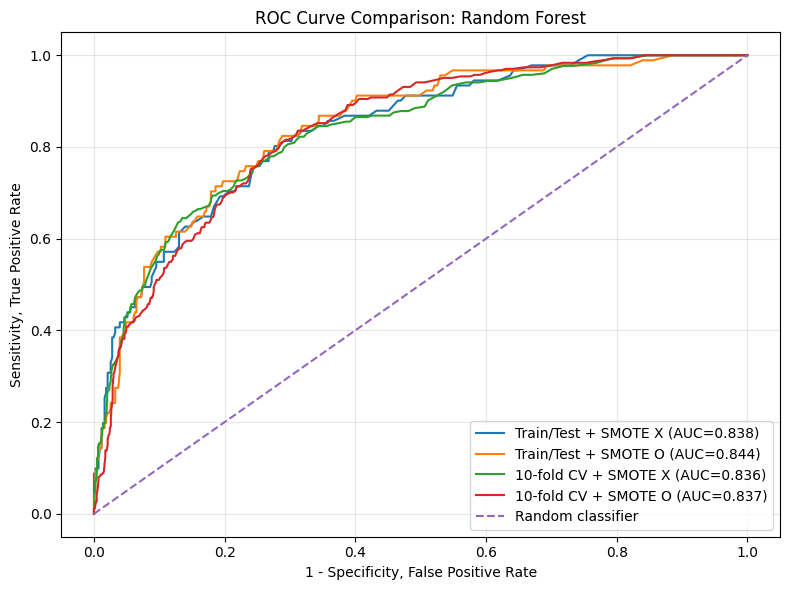

In [ ]:
# ROC Curve 4개 조건 비교
plt.figure(figsize=(8, 6))

all_roc = {**holdout_roc, **cv_roc}

for label, (fpr, tpr, auc_value) in all_roc.items():
    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("1 - Specificity, False Positive Rate")
plt.ylabel("Sensitivity, True Positive Rate")
plt.title("ROC Curve Comparison: Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rf_roc_comparison.png", dpi=300)
plt.show()

In [ ]:
# 변수 중요도 분석
#     최종 모델은 SMOTE 적용 모델 기준으로 확인
final_model = make_rf_pipeline(use_smote=True)
final_model.fit(X_train, y_train)

feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
feature_names = [
    name.replace("cat__", "").replace("num__", "")
    for name in feature_names
]

importances = final_model.named_steps["rf"].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\n==============================")
print("변수 중요도 상위 20개")
print("==============================")
print(importance_df.head(20).round(4))

importance_df.to_csv(
    "rf_variable_importance_smote.csv",
    index=False,
    encoding="utf-8-sig"
)


변수 중요도 상위 20개
            Variable  Importance
4   letters_received      0.2136
9  smoking_start_age      0.1584
1   age_at_admission      0.1569
3  delinquency_count      0.1105
2  first_offense_age      0.0855
6   antisocial_score      0.0784
7         adhd_score      0.0781
5      runaway_count      0.0669
8    runaway_history      0.0357
0           gender_M      0.0160


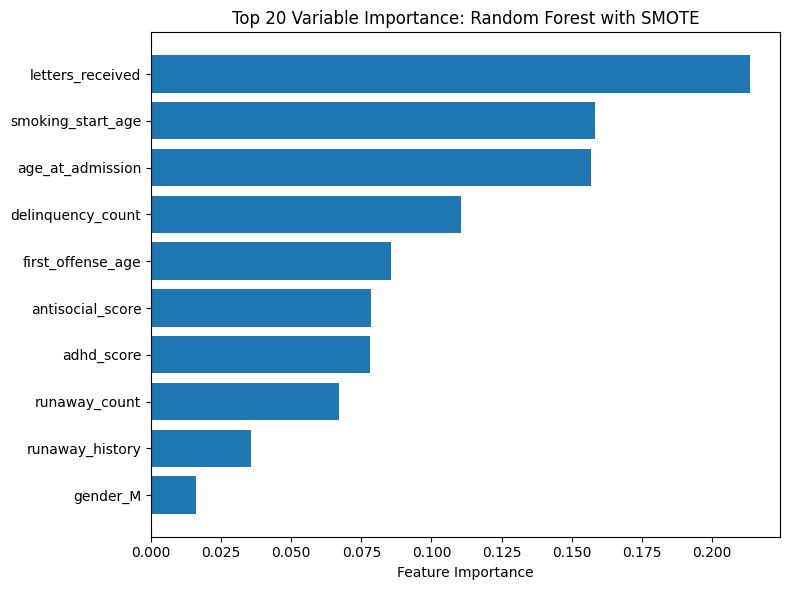

In [ ]:
# 변수 중요도 그래프
top_n = 20
top_imp = importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_imp["Variable"], top_imp["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 20 Variable Importance: Random Forest with SMOTE")
plt.tight_layout()
plt.savefig("rf_variable_importance_smote.png", dpi=300)
plt.show()